<h1>Online Course Recommendation System </h1>
Problem Statement<br>
The goal of this dataset is to build an online course recommendation system that suggests
relevant courses to learners based on their interests, past enrollments, and engagement
levels. The dataset includes course ratings, instructor information, previous learning
history, study material availability, and certification offerings, making it suitable for
recommendation models using collaborative filtering, content-based filtering, or hybrid
approaches.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel("online_course_recommendation.xlsx")

In [3]:
df.shape

(100000, 14)

In [4]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [6]:
df.describe()

,user_id,course_id,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,24935.663570,5006.863560,52.38354,3.959859,25052.822850,261.073369,0.746865,20.691054,4.992670
std,14406.960108,2882.085456,27.42347,0.729958,14388.188356,139.013758,0.143683,13.669148,2.237259
min,1.000000,1.000000,5.00000,1.000000,50.000000,20.000000,0.092000,1.000000,0.000000
25%,12487.750000,2523.000000,28.60000,3.500000,12583.750000,140.100000,0.649000,9.900000,3.000000
50%,24793.500000,5012.000000,52.40000,4.000000,25057.500000,262.310000,0.750000,19.920000,5.000000
75%,37382.250000,7502.000000,76.10000,4.500000,37522.000000,381.702500,0.851000,30.080000,6.000000
max,49999.000000,9999.000000,100.00000,5.000000,49999.000000,500.000000,1.000000,84.150000,19.000000


In [7]:
df.isnull().sum()

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#Top 5 popular courses
courses=df["course_name"].value_counts().sort_values(ascending=False)[:5]
courses

course_name
Networking and System Administration    5107
Cybersecurity for Professionals         5078
Advanced Machine Learning               5063
Ethical Hacking Masterclass             5062
Graphic Design with Canva               5057
Name: count, dtype: int64

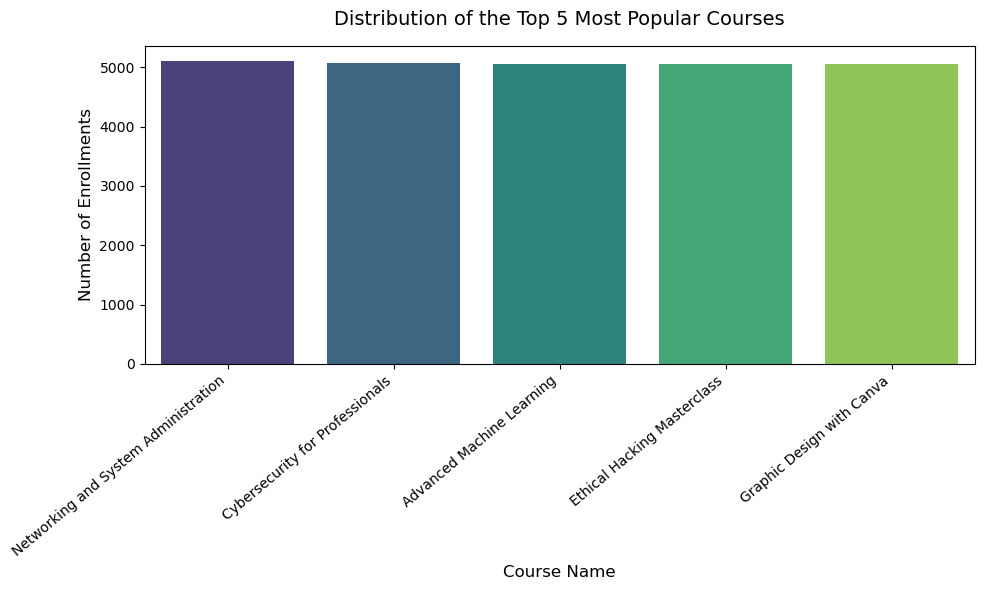

In [10]:
# Filter the dataframe to only include the top 5 courses
df_top_5 = df[df["course_name"].isin(courses.index)]

# Plot the count distribution for the top 5 courses
plt.figure(figsize=(10, 6))
sns.countplot(data=df_top_5, x="course_name", order=courses.index, palette="viridis")

# Clean up the labels and rotate text to prevent overlapping
plt.title("Distribution of the Top 5 Most Popular Courses", fontsize=14, pad=15)
plt.xlabel("Course Name", fontsize=12)
plt.ylabel("Number of Enrollments", fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df.rating.nunique()
#we have 31 unique ratings in our dataset

41

In [12]:
ratings=df["rating"].value_counts().sort_values(ascending=False).head(5)
ratings
# Most users rated courses 5.0 (11,868 times), revealing a positive rating bias in the dataset.

rating
5.0    11868
4.0     5101
4.1     4986
3.9     4883
3.8     4860
Name: count, dtype: int64

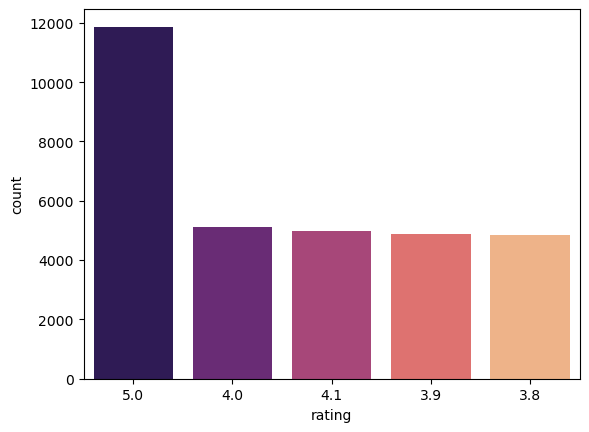

In [13]:
sns.barplot(data=ratings,order=ratings.index,palette='magma')
plt.show()

Index(['Beginner', 'Intermediate', 'Advanced'], dtype='object', name='difficulty_level')


<Axes: xlabel='difficulty_level', ylabel='count'>

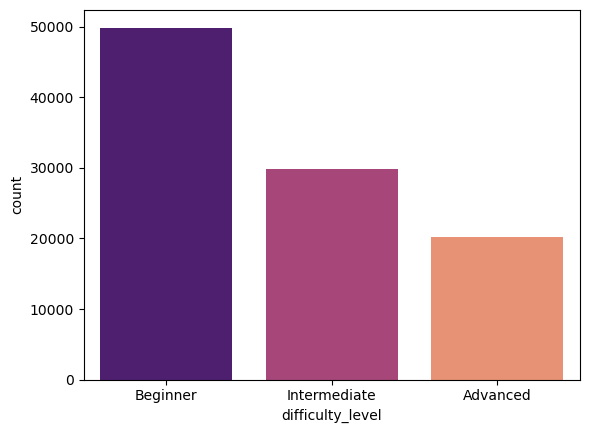

In [14]:
# 1. Get the category order sorted by frequency in descending order
difficulty_order = df['difficulty_level'].value_counts().index
print(difficulty_order)

# 2. Plot the ordered countplot
sns.countplot(data=df, x='difficulty_level', palette='magma', order=difficulty_order)


In [15]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [16]:
print(df.certification_offered.value_counts())
name=df.certification_offered.value_counts().index
label=df.certification_offered.value_counts().values

certification_offered
Yes    70059
No     29941
Name: count, dtype: int64


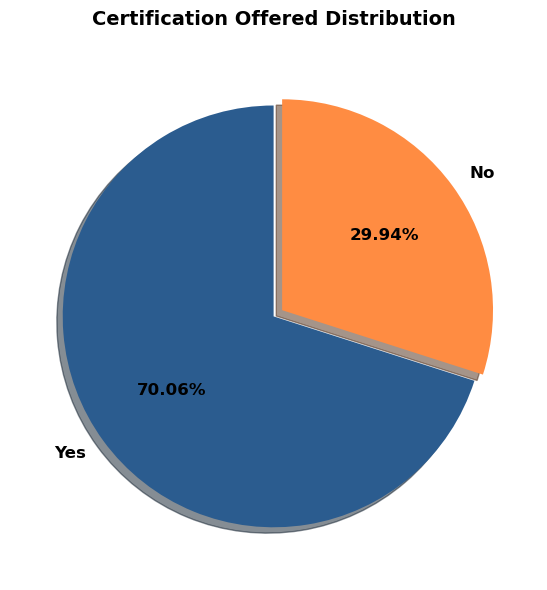

In [17]:
# Modern color palette (Soft Blue and Coral Orange)
colors = ['#2b5c8f', '#ff8c42']

plt.figure(figsize=(6, 6)) # Forces it to be a perfect circle
plt.pie(
    label, 
    labels=name, 
    autopct='%.2f%%', 
    colors=colors,
    startangle=90,          # Rotates the starting point for better alignment
    explode=(0, 0.05),      # Slightly pulls out the "No" slice for emphasis
    shadow=True,            # Adds depth with a soft drop shadow
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'}# Styles text,    
)
plt.title('Certification Offered Distribution', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()


In [18]:
num_col=[i for i in df.columns if df[i].dtype=='float']
num_col

['course_duration_hours',
 'rating',
 'course_price',
 'feedback_score',
 'time_spent_hours']

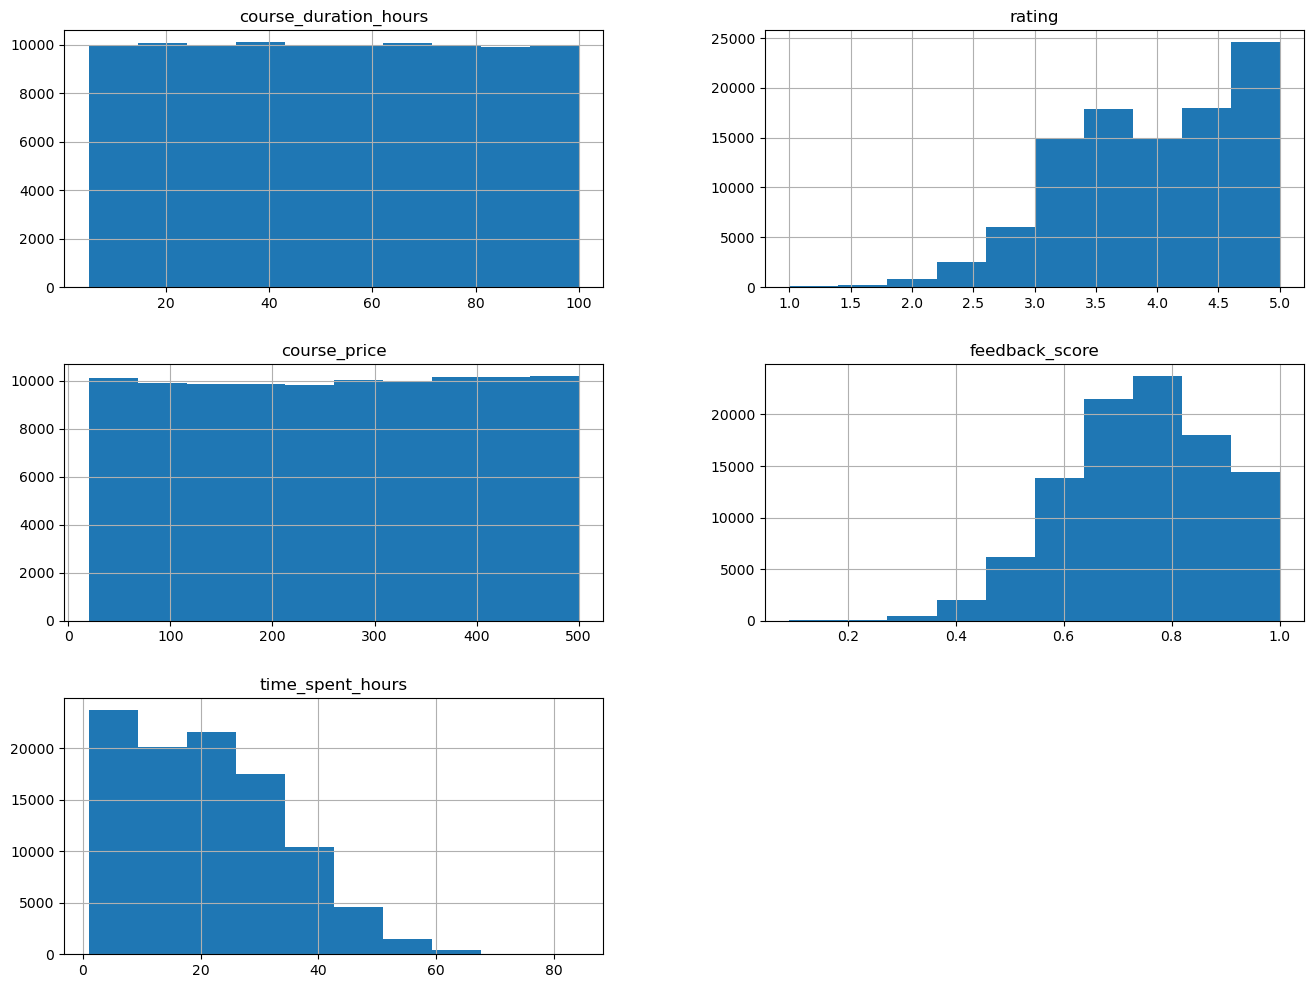

In [19]:
num_col=[i for i in df.columns if df[i].dtype=='float']

df[num_col].hist(figsize=(16, 12), bins=10)
plt.show()


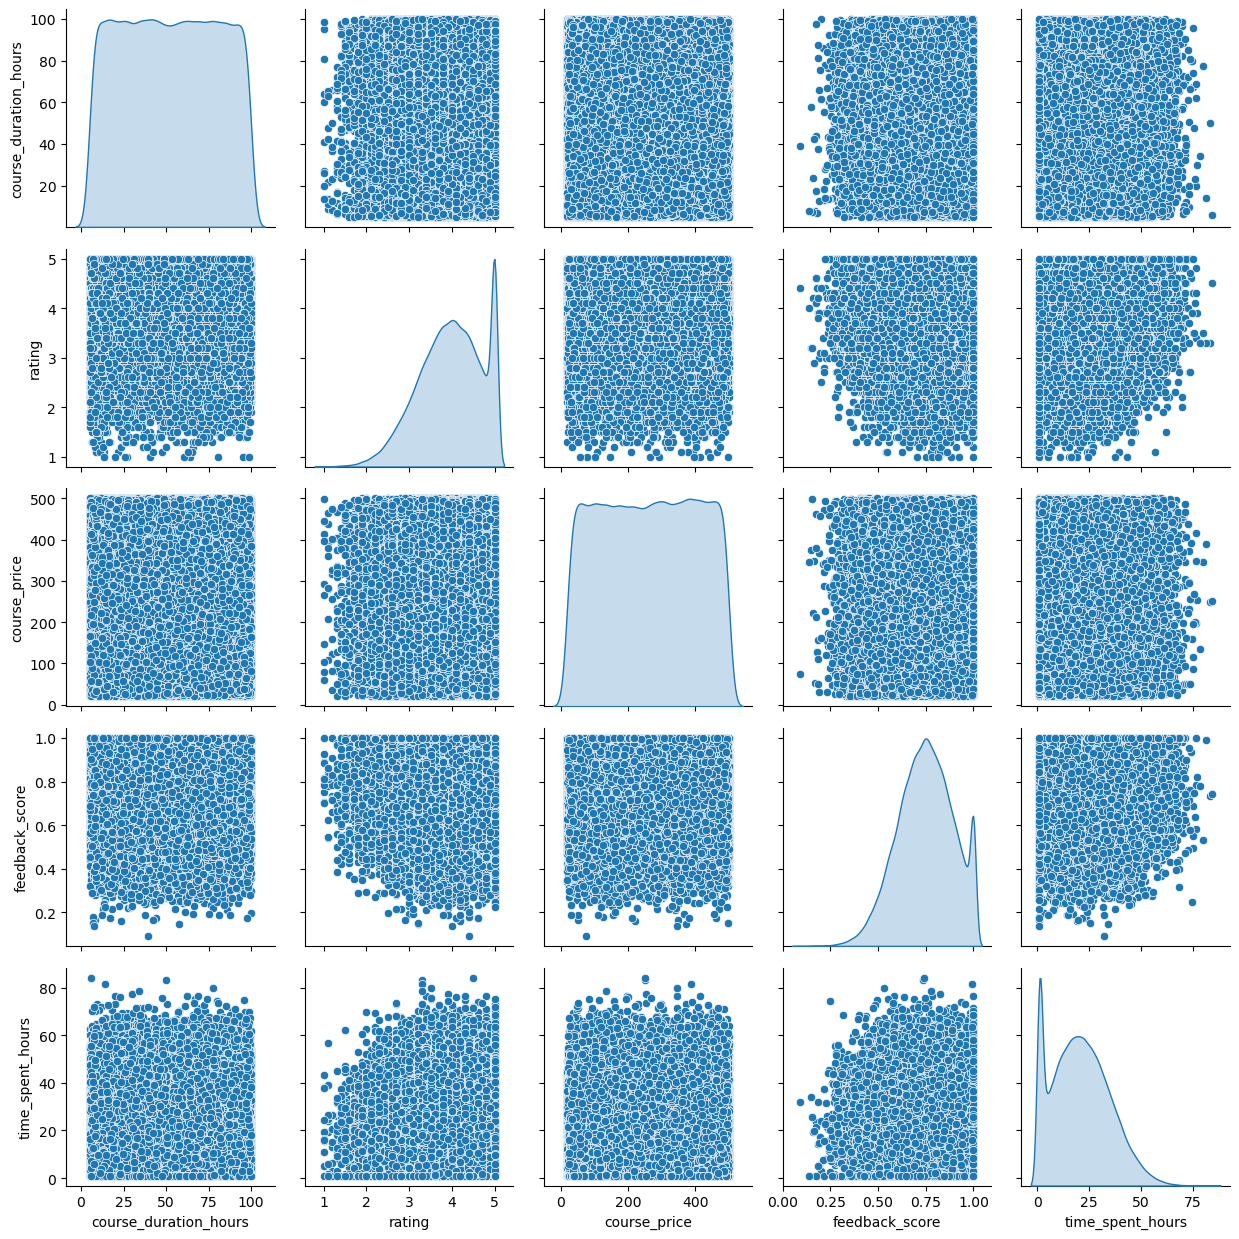

In [20]:
#pair plot
# Select only a few columns of interest to compare
sns.pairplot(df[num_col],diag_kind="kde")
plt.tight_layout()
plt.show()

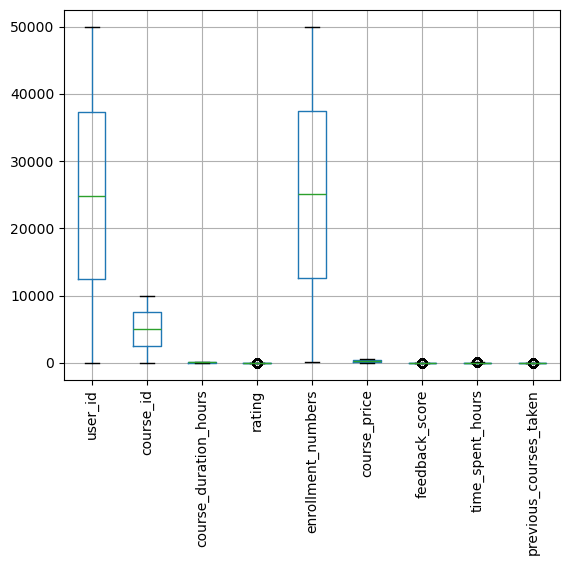

In [21]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

Outliers are present in columns.We have to replace to these with lower extreme and upper extreme

In [22]:
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x : lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x )
for col in df.select_dtypes([int,float]).columns:
        outlier_capping(df,col)

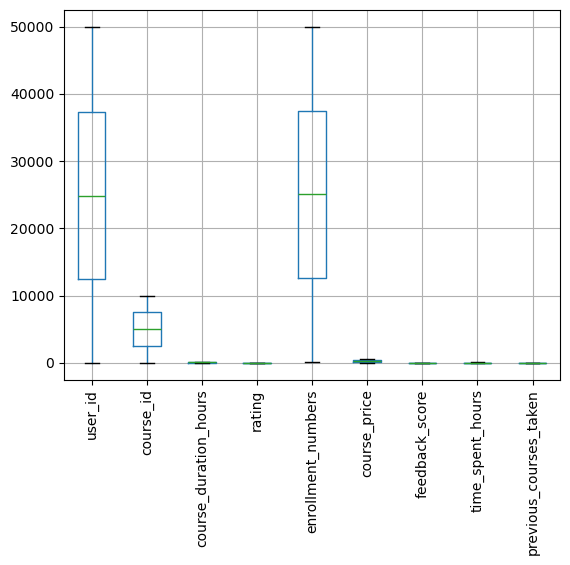

In [23]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [24]:
for col in df.select_dtypes(['int','float']).columns:
    print(col)

user_id
course_id
course_duration_hours
rating
enrollment_numbers
course_price
feedback_score
time_spent_hours
previous_courses_taken


<Axes: >

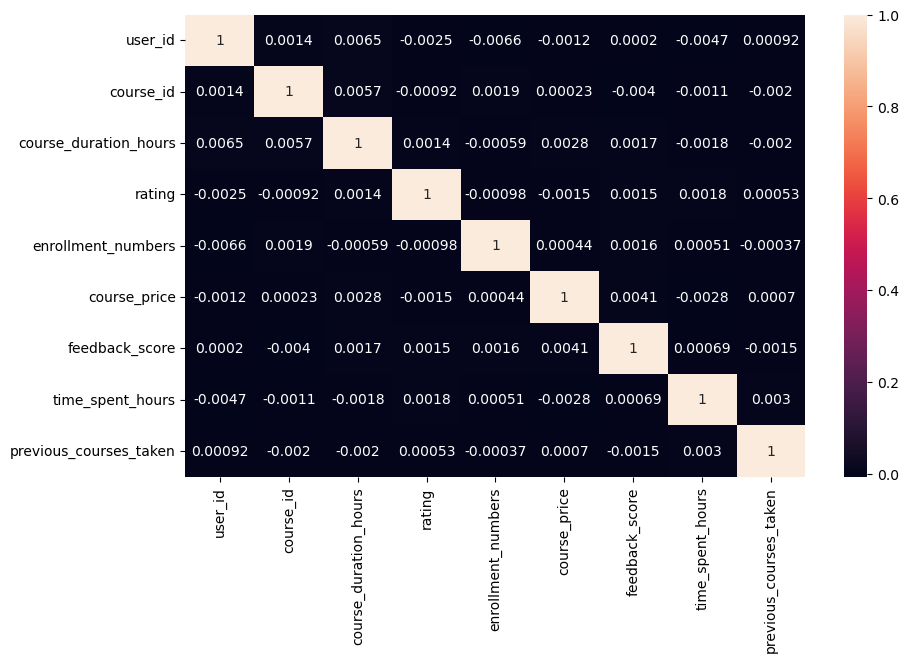

In [25]:
plt.figure(figsize=(10,6))
corr=df[["user_id","course_id","course_duration_hours","rating","enrollment_numbers","course_price","feedback_score","time_spent_hours",
         "previous_courses_taken"]].corr()
sns.heatmap(corr,annot=True)

### 📊 Correlation Heatmap Insights

A Pearson correlation matrix was computed across the numerical features to identify linear relationships within the dataset:

* **Weak Multi-Collinearity**: All correlation coefficients are extremely close to zero (ranging between roughly -0.006 and 0.006). 
* **Independent Features**: No strong positive or negative relationships exist between variables like `course_price`, `rating`, `time_spent_hours`, or `enrollment_numbers`.
* **Modeling Impact**: This lack of correlation indicates that the numerical features are highly independent, meaning they provide distinct, non-redundant information for a recommendation model.


In [26]:
df[df["course_id"]==9366]

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4.0
7350,4632,9366,DevOps and Continuous Deployment,Sophia Anderson,8.7,No,Beginner,3.3,20884,308.20,0.636,Yes,12.61,5.0
10129,26785,9366,Photography and Video Editing,Prof. Emily Johnson,62.1,Yes,Advanced,5.0,10504,23.54,0.876,Yes,16.32,2.0
18756,24513,9366,Advanced Machine Learning,David Wilson,75.6,Yes,Beginner,4.1,19718,52.71,0.540,Yes,21.98,9.0
59294,8407,9366,AI for Business Leaders,Olivia Taylor,93.2,Yes,Advanced,3.8,36671,148.59,0.797,Yes,18.34,3.0
71667,17632,9366,Photography and Video Editing,James Clark,32.9,Yes,Intermediate,4.5,16963,58.74,0.920,Yes,20.09,7.0
90810,48987,9366,DevOps and Continuous Deployment,Dr. John Smith,7.8,Yes,Advanced,4.5,3976,51.05,0.674,Yes,23.19,6.0
96424,9770,9366,Python for Beginners,James Clark,92.3,No,Beginner,3.0,32323,59.65,0.690,Yes,45.66,2.0
97808,7672,9366,Python for Beginners,Sophia Anderson,18.3,No,Intermediate,3.6,6755,289.42,0.791,Yes,14.12,1.0


##### we can see that for course_id 9366 we have different courses and their difficult levels are also different.so course_id cannot uniquely identify a course

In [27]:
df[df["course_name"]=="Python for Beginners"]

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4.0
16,5312,3455,Python for Beginners,Charlotte King,11.1,Yes,Beginner,4.6,43655,426.00,0.966,Yes,22.80,5.0
89,21272,4455,Python for Beginners,Isabella Scott,54.4,No,Intermediate,2.7,21632,310.15,0.640,Yes,22.87,1.0
119,35223,9560,Python for Beginners,James Clark,67.0,Yes,Beginner,4.4,34147,275.50,0.624,Yes,6.07,4.0
125,24539,9355,Python for Beginners,Charlotte King,58.8,No,Advanced,4.4,23131,391.06,0.653,Yes,23.00,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99943,39735,6911,Python for Beginners,James Clark,65.1,No,Beginner,4.4,25454,438.12,0.845,No,1.00,1.0
99948,48737,2069,Python for Beginners,Daniel White,9.4,Yes,Beginner,3.4,24142,334.53,0.826,Yes,26.32,6.0
99975,1150,6111,Python for Beginners,Isabella Scott,83.3,No,Beginner,5.0,40767,127.12,0.646,Yes,34.90,9.0
99980,17005,5325,Python for Beginners,Sarah Lee,32.3,Yes,Beginner,3.1,1484,455.74,0.572,Yes,32.73,4.0


##### Even with the same course names,the difficulty levels are different.

In [28]:
df[(df["course_name"]=="Python for Beginners") & (df["difficulty_level"]=="Beginner")]

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4.0
16,5312,3455,Python for Beginners,Charlotte King,11.1,Yes,Beginner,4.6,43655,426.00,0.966,Yes,22.80,5.0
119,35223,9560,Python for Beginners,James Clark,67.0,Yes,Beginner,4.4,34147,275.50,0.624,Yes,6.07,4.0
173,15708,716,Python for Beginners,Sophia Anderson,96.6,Yes,Beginner,3.2,30163,292.35,0.846,Yes,18.37,5.0
292,12184,1334,Python for Beginners,Alexander Young,11.7,No,Beginner,3.9,18018,213.23,0.880,Yes,16.10,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99943,39735,6911,Python for Beginners,James Clark,65.1,No,Beginner,4.4,25454,438.12,0.845,No,1.00,1.0
99948,48737,2069,Python for Beginners,Daniel White,9.4,Yes,Beginner,3.4,24142,334.53,0.826,Yes,26.32,6.0
99975,1150,6111,Python for Beginners,Isabella Scott,83.3,No,Beginner,5.0,40767,127.12,0.646,Yes,34.90,9.0
99980,17005,5325,Python for Beginners,Sarah Lee,32.3,Yes,Beginner,3.1,1484,455.74,0.572,Yes,32.73,4.0


##### Now each row/data entry has the same course name and difficulty level

##### So we choose course_name+difficulty_level as unique key.we applied different aggregate fucntions based on each column's data type and created  a unique row for each of the course_key and added them to course_catalog dataframe

In [29]:
df['course_key'] = df['course_name'] + " | " + df['difficulty_level']

course_catalog = df.groupby('course_key').agg(
    course_name           = ('course_name', 'first'),
    difficulty_level      = ('difficulty_level', 'first'),
    avg_duration          = ('course_duration_hours', 'median'),
    avg_price             = ('course_price', 'median'),
    certification_offered = ('certification_offered', lambda x: x.mode()[0]),
    study_material        = ('study_material_available', lambda x: x.mode()[0]),
    avg_rating            = ('rating', 'mean'),
    avg_feedback          = ('feedback_score', 'mean'),
    total_enrollments     = ('user_id', 'count'),
    avg_time_spent        = ('time_spent_hours', 'mean')
).reset_index()

print(f"Total unique courses: {len(course_catalog)}")

Total unique courses: 60


In [30]:
course_catalog.head()

,course_key,course_name,difficulty_level,avg_duration,avg_price,certification_offered,study_material,avg_rating,avg_feedback,total_enrollments,avg_time_spent
0,AI for Business Leaders | Advanced,AI for Business Leaders,Advanced,53.4,262.400,Yes,Yes,3.926390,0.744893,989,20.036855
1,AI for Business Leaders | Beginner,AI for Business Leaders,Beginner,53.0,265.400,Yes,Yes,3.961938,0.749870,2559,20.680785
2,AI for Business Leaders | Intermediate,AI for Business Leaders,Intermediate,48.7,252.050,Yes,Yes,3.963674,0.749908,1459,19.817608
3,Advanced Machine Learning | Advanced,Advanced Machine Learning,Advanced,52.5,255.960,Yes,Yes,3.962018,0.741452,1011,20.603581
4,Advanced Machine Learning | Beginner,Advanced Machine Learning,Beginner,52.9,259.915,Yes,Yes,3.974096,0.748406,2544,20.672807


### content based recommendation

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

# Text feature: course_name keywords
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(course_catalog['course_name'])
      
# Numeric features
#values between 0 and 1
scaler = MinMaxScaler()
numeric = scaler.fit_transform(course_catalog[['avg_duration', 'avg_price']])

# Encode difficulty
#values between 0 and 1
difficulty_map = {'Beginner': 0.0, 'Intermediate': 0.5, 'Advanced': 1.0}
course_catalog['difficulty_encoded'] = course_catalog['difficulty_level'].map(difficulty_map)

difficulty_col = course_catalog[['difficulty_encoded']].values
#gives values in array form

# Combine all,using horizontal stacking
numeric_all = np.hstack([numeric, difficulty_col])
#compressed sparse matrix
combined = hstack([tfidf_matrix * 0.7, csr_matrix(numeric_all * 0.3)])

#finding course to course similairity,course name has an edge in this computation,difficulty level,avg_duration and avg_price are also taken into consideration
content_sim = cosine_similarity(combined, combined)

In [32]:
def recom_course(similar_course, dif_level):
    
    # Step 1 — Check if course exists in catalog
    match = (course_catalog["course_name"] == similar_course) & (course_catalog["difficulty_level"] == dif_level) #returns as true or false
    
    if match.any():  # .any() checks if at least one row matches
        
        # Step 2 — Get the row index of the matched course
        index = match[match == True].index[0]  # gets the actual integer index
        
        # Step 3 — Get similarity scores for this course vs all others
        # content_sim[index] → one row → similarity of this course with every course
        similar_indices = sorted(
            list(enumerate(content_sim[index])),  # [(0, 0.9), (1, 0.3), ...]
            reverse=True,                          # highest similarity first
            key=lambda x: x[1]                    # sort by score not index
        )[1:11]  # skip index 0 (that's the course itself, always score=1.0)
        
        # Step 4 — Print recommendations with full course details
        print(f"\n📚 Because you liked: '{similar_course} | {dif_level}'")
        print(f"Here are your top recommended courses:\n")
        print(f"{'#':<4} {'Course Name':<45} {'Difficulty':<15} {'Avg Rating':<12} {'Avg Price':<12} {'Similarity'}")
        print("-" * 100)
        
        for rank, (index, score) in enumerate(similar_indices, start=1):
            row = course_catalog.iloc[index]  # fetch full course details by position
            print(f"{rank:<4} {row['course_name']:<45} {row['difficulty_level']:<15} "
                  f"{row['avg_rating']:<12.2f} {row['avg_price']:<12.2f} {score:.4f}")
    
    else:
        print(f"❌ Course '{similar_course} | {dif_level}' not found in catalog.")
        print("Available difficulty levels: Beginner, Intermediate, Advanced")
        
    

In [33]:
recom_course("Python for Beginners","Intermediate")


📚 Because you liked: 'Python for Beginners | Intermediate'
Here are your top recommended courses:

#    Course Name                                   Difficulty      Avg Rating   Avg Price    Similarity
----------------------------------------------------------------------------------------------------
1    Python for Beginners                          Advanced        3.95         261.67       0.9814
2    Python for Beginners                          Beginner        3.97         260.90       0.9793
3    Personal Finance and Wealth Building          Advanced        3.98         273.80       0.2038
4    Ethical Hacking Masterclass                   Advanced        3.94         266.49       0.1982
5    Stock Market and Trading Strategies           Advanced        3.91         277.50       0.1940
6    Ethical Hacking Masterclass                   Intermediate    4.00         271.05       0.1919
7    Project Management Fundamentals               Advanced        3.96         262.38       0.

### collaborative based filtering

In [34]:
# Build user-course interaction matrix using rating as signal
user_course_matrix = df.pivot_table(
    index='user_id',
    columns='course_key',       # use our reliable composite key
    values='rating',
    aggfunc='mean'
).fillna(0)

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# User-user similarity
user_sim = cos_sim(user_course_matrix)
user_sim_df = pd.DataFrame(
    user_sim,
    index=user_course_matrix.index,
    columns=user_course_matrix.index
)

In [35]:
def similar_users(user_id):
    if user_id in user_sim_df.index:
        top_n=10
         # Step 1 — Find 10 most similar users
        similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:11].index
        
        # Step 2 — Get their ratings and average course by course
        collab_scores = user_course_matrix.loc[similar_users].mean(axis=0)
        
        # Step 3 — Normalize between 0 and 1
        collab_scores = (collab_scores - collab_scores.min()) / \
                        (collab_scores.max() - collab_scores.min() + 1e-9)
        
        # Step 4 — Find courses our target user already took
        courses_taken = set(user_course_matrix.loc[user_id][user_course_matrix.loc[user_id] > 0].index)
        
        # Step 5 — Remove already taken courses from recommendations
        collab_scores = collab_scores[~collab_scores.index.isin(courses_taken)]
        
        # Step 6 — Sort and get top N
        top_courses = collab_scores.sort_values(ascending=False).head(top_n)
        
        # Step 7 — Print results
        print(f"\n👤 User ID: {user_id}")
        print(f"👥 Similar Users Found: {list(similar_users)}\n")
        print(f"📚 Top {top_n} Recommended Courses based on similar users:\n")
        print(f"{'#':<4} {'Course Key':<70} {'Collab Score'}")
        print("-" * 70)
        
        for rank, (course_key, score) in enumerate(top_courses.items(), start=1):
            # Split course_key back into name and difficulty
            parts = course_key.split(" | ")
            course_name = parts[0]
            difficulty  = parts[1] if len(parts) > 1 else "N/A"
            print(f"{rank:<4} {course_name:<55} {difficulty:<15} {score:.4f}")
    else:
        print("User id not in the list")

In [36]:
similar_users(15796)


👤 User ID: 15796
👥 Similar Users Found: [48035, 30930, 21756, 42839, 24224, 11643, 36933, 36417, 38288, 33379]

📚 Top 10 Recommended Courses based on similar users:

#    Course Key                                                             Collab Score
----------------------------------------------------------------------
1    AI for Business Leaders                                 Advanced        0.0000
2    AI for Business Leaders                                 Beginner        0.0000
3    AI for Business Leaders                                 Intermediate    0.0000
4    Advanced Machine Learning                               Advanced        0.0000
5    Advanced Machine Learning                               Beginner        0.0000
6    Advanced Machine Learning                               Intermediate    0.0000
7    Blockchain and Decentralized Applications               Advanced        0.0000
8    Blockchain and Decentralized Applications               Beginner        0.0000
9

### Final Hybrid Recommendation Function

### content based filtering

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

# Text feature: course_name keywords
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(course_catalog['course_name'])
      
# Numeric features
scaler = MinMaxScaler()
numeric = scaler.fit_transform(course_catalog[['avg_duration', 'avg_price']])

# Encode difficulty
difficulty_map = {'Beginner': 0.0, 'Intermediate': 0.5, 'Advanced': 1.0}
course_catalog['difficulty_encoded'] = course_catalog['difficulty_level'].map(difficulty_map)

difficulty_col = course_catalog[['difficulty_encoded']].values

# Combine all
numeric_all = np.hstack([numeric, difficulty_col])
combined = hstack([tfidf_matrix * 0.7, csr_matrix(numeric_all * 0.3)])

content_sim = cosine_similarity(combined, combined)

### collaborative based

In [38]:
# Build user-course interaction matrix using rating as signal
user_course_matrix = df.pivot_table(
    index='user_id',
    columns='course_key',       # use our reliable composite key
    values='rating',
    aggfunc='mean'
).fillna(0)

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# User-user similarity
user_sim = cos_sim(user_course_matrix)
user_sim_df = pd.DataFrame(
    user_sim,
    index=user_course_matrix.index,
    columns=user_course_matrix.index
)

### engagement boost

In [39]:
# Normalize engagement signals as a ranking boost
#create a new column named engagement_score ,calculates the average for the 4 columns across columns(row-wise)
course_catalog['engagement_score'] = scaler.fit_transform(
    course_catalog[['avg_rating', 'avg_feedback', 'avg_time_spent', 'total_enrollments']]
).mean(axis=1)

In [40]:
def hybrid_recommend(user_id, top_n=5, 
                     w_content=0.5, w_collab=0.3, w_engage=0.2):

    # ── Collaborative score ──
    if user_id in user_sim_df.index:
        similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:11].index
        collab_scores = user_course_matrix.loc[similar_users].mean(axis=0)
        collab_scores = (collab_scores - collab_scores.min()) / \
                        (collab_scores.max() - collab_scores.min() + 1e-9)
    else:
        collab_scores = pd.Series(0, index=course_catalog['course_key'])

    # ── Content score based on previous_courses_taken ──
    user_courses = df[df['user_id'] == user_id]['course_key'].unique()  #finds the courses user already taken
    content_scores = np.zeros(len(course_catalog))
    course_index = pd.Series(course_catalog.index, index=course_catalog['course_key'])
    #creates a series with index as course_key and value as the index of course key
    
  

    for ck in user_courses:
        if ck in course_index:
            idx = course_index[ck]
            content_scores += content_sim[idx]

    content_scores = (content_scores - content_scores.min()) / \
                     (content_scores.max() - content_scores.min() + 1e-9)

    # ── Engagement score ──
    engage_scores = course_catalog['engagement_score'].values

    # ── Hybrid ──
    collab_array = collab_scores.reindex(
        course_catalog['course_key']).fillna(0).values

    final_scores = (w_content * content_scores +
                    w_collab  * collab_array +
                    w_engage  * engage_scores)

    # Remove already-enrolled courses
    course_catalog['final_score'] = final_scores
    already_enrolled = set(user_courses)
    recommendations = course_catalog[
        ~course_catalog['course_key'].isin(already_enrolled)
    ].sort_values('final_score', ascending=False)

    return recommendations[['course_name', 'difficulty_level','avg_rating', 'avg_price','final_score']].head(top_n)



In [41]:
hybrid_recommend(15796,top_n=10)

,course_name,difficulty_level,avg_rating,avg_price,final_score
56,Python for Beginners,Intermediate,4.017799,264.335,0.600358
20,DevOps and Continuous Deployment,Intermediate,3.950165,262.690,0.591222
54,Python for Beginners,Advanced,3.953964,261.670,0.538958
18,DevOps and Continuous Deployment,Advanced,3.972674,254.260,0.538210
23,Ethical Hacking Masterclass,Intermediate,4.000134,271.050,0.217164
13,Cybersecurity for Professionals,Beginner,3.972127,265.890,0.211727
1,AI for Business Leaders,Beginner,3.961938,265.400,0.207257
52,Public Speaking Mastery,Beginner,3.936056,266.880,0.204464
31,Game Development with Unity,Beginner,3.960187,261.080,0.202119
28,Fundamentals of Digital Marketing,Beginner,3.969354,271.085,0.199891


In [42]:
df[df["user_id"]==15796]

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken,course_key
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4.0,Python for Beginners | Beginner
25777,15796,1741,DevOps and Continuous Deployment,Liam Adams,40.3,Yes,Beginner,3.6,14706,261.54,0.935,Yes,49.88,6.0,DevOps and Continuous Deployment | Beginner


#### Evaluation

In [43]:
import numpy as np
from sklearn.model_selection import train_test_split

# ── Step 1: Take a Small Sample ───────────────────────────────────────
sample_users = df['user_id'].unique()[:5]   # only 100 users
sample_df    = df[df['user_id'].isin(sample_users)]

# ── Step 2: Train Test Split on Sample ───────────────────────────────
train_df, test_df = train_test_split(sample_df, test_size=0.2, random_state=42)

# ── Step 3: Wrapper Functions ─────────────────────────────────────────
content_recommend_fn = lambda user_id, top_n: content_recommend(user_id, top_n=top_n)
collab_recommend_fn  = lambda user_id, top_n: similar_users(user_id, top_n=top_n)
hybrid_recommend_fn  = lambda user_id, top_n: hybrid_recommend(user_id, top_n=top_n)

# ── Step 4: Evaluation Function ───────────────────────────────────────
def evaluate_model(recommend_func, test_df, k=5):
    precisions = []
    recalls    = []
    
    # ✅ Only loop through 50 users instead of all users
    sample_test_users = test_df['user_id'].unique()[:5]
    
    for user_id in sample_test_users:
        actual = set(test_df[test_df['user_id'] == user_id]['course_key'])
        
        try:
            recommended = set(recommend_func(user_id, top_n=k)['course_key'])
        except:
            continue
        
        hits      = actual & recommended
        precision = len(hits) / k
        recall    = len(hits) / len(actual) if actual else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall    = np.mean(recalls)    if recalls    else 0
    
    return avg_precision, avg_recall

# ── Step 5: Evaluate All 3 Models ────────────────────────────────────
print("Evaluating all models on sample...\n")

p_content, r_content = evaluate_model(content_recommend_fn, test_df, k=5)
print("✅ Content Based Done")

p_collab,  r_collab  = evaluate_model(collab_recommend_fn,  test_df, k=5)
print("✅ Collaborative Done")

p_hybrid,  r_hybrid  = evaluate_model(hybrid_recommend_fn,  test_df, k=5)
print("✅ Hybrid Done")

# ── Step 6: Display Results ───────────────────────────────────────────
print("\n" + "=" * 55)
print(f"{'Model':<20} {'Precision@5':<18} {'Recall@5':<10}")
print("=" * 55)
print(f"{'Content Based':<20} {p_content:<18.4f} {r_content:<10.4f}")
print(f"{'Collaborative':<20} {p_collab:<18.4f}  {r_collab:<10.4f}")
print(f"{'Hybrid':<20} {p_hybrid:<18.4f}  {r_hybrid:<10.4f}")
print("=" * 55)

# ── Step 7: Pick Best Model ───────────────────────────────────────────
models = {
    'Content Based' : (p_content, r_content),
    'Collaborative' : (p_collab,  r_collab),
    'Hybrid'        : (p_hybrid,  r_hybrid)
}

best_model = max(models, key=lambda x: models[x][0])
print(f"\n✅ Best Model  : {best_model}")
print(f"   Precision@5 : {models[best_model][0]:.4f}")
print(f"   Recall@5    : {models[best_model][1]:.4f}")

Evaluating all models on sample...

✅ Content Based Done
✅ Collaborative Done
✅ Hybrid Done

Model                Precision@5        Recall@5  
Content Based        0.0000             0.0000    
Collaborative        0.0000              0.0000    
Hybrid               0.0000              0.0000    

✅ Best Model  : Content Based
   Precision@5 : 0.0000
   Recall@5    : 0.0000


In [49]:
import joblib

joblib.dump(content_sim,        "content_sim.pkl")
joblib.dump(user_course_matrix, "user_course_matrix.pkl")
joblib.dump(course_catalog,     "course_catalog.pkl")
print("success")

success


In [53]:
joblib.dump(df, "df.pkl")

['df.pkl']

In [52]:
pwd

'C:\\Users\\jidhi\\Project3'